[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TheGhoul21/QC-notebooks/blob/main/QC-Intro/00_qubits_and_superposition.ipynb)

# Qubit e Superposizione — Stati, Ampiezze e Misura

**Notebook 0** della serie *QC-Intro: Il Quantum Computing attraverso l'Interferenza*

In questo notebook esploreremo i concetti fondamentali del quantum computing: il qubit come generalizzazione del bit classico, le ampiezze complesse, la sfera di Bloch, la misura quantistica, il prodotto tensoriale e l'entanglement.


In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, FloatSlider, IntSlider

from qc_intro_utils import (
    apply_style, draw_bloch_sphere, draw_amplitude_bars,
    simulate_measurement, draw_complex_plane,
    PRIMARY_COLOR, ACCENT_COLOR, GHOST_COLOR, phase_to_color
)

apply_style()
%matplotlib inline

---

## 1. Bit classico vs qubit

Un **bit classico** vive nell'insieme discreto $\{0, 1\}$. Un **qubit** è un vettore unitario nello spazio di Hilbert $\mathbb{C}^2$:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \qquad |\alpha|^2 + |\beta|^2 = 1$$

dove $\alpha, \beta \in \mathbb{C}$ sono le **ampiezze di probabilità**.

### Parametrizzazione della sfera di Bloch

A meno di una fase globale, ogni stato di un qubit si può scrivere come:

$$|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\varphi}\sin\frac{\theta}{2}|1\rangle$$

con $\theta \in [0, \pi]$ e $\varphi \in [0, 2\pi)$. Questa parametrizzazione mappa ogni stato puro su un punto della **sfera di Bloch**:
- $|0\rangle$: polo nord ($\theta = 0$)
- $|1\rangle$: polo sud ($\theta = \pi$)
- $|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$: equatore ($\theta = \pi/2, \varphi = 0$)

### Forward: tre stati sulla sfera di Bloch

Visualizziamo tre stati fondamentali: $|0\rangle$, $|+\rangle$ e uno stato generico con $\theta = \pi/3, \varphi = \pi/4$.

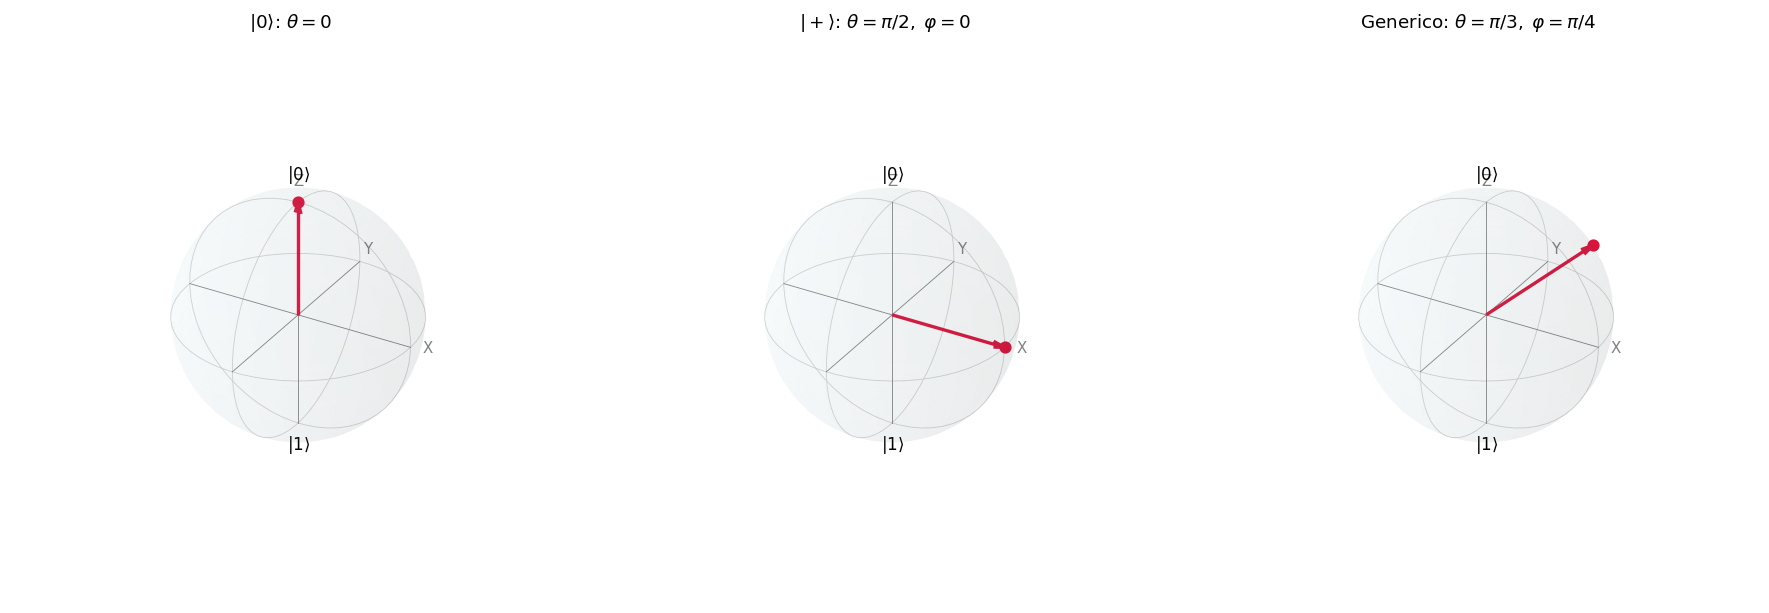

In [2]:
# Forward: three key states on the Bloch sphere
fig = plt.figure(figsize=(15, 5))

states = [
    (0, 0, r'$|0\rangle$: $\theta=0$'),
    (np.pi/2, 0, r'$|+\rangle$: $\theta=\pi/2,\;\varphi=0$'),
    (np.pi/3, np.pi/4, r'Generico: $\theta=\pi/3,\;\varphi=\pi/4$'),
]

for i, (theta, phi, title) in enumerate(states):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    draw_bloch_sphere(theta, phi, ax=ax, title=title)

plt.tight_layout()
plt.show()

### Backward: "Se misuro sempre 50/50, che stati possono essere?"

Se $P(0) = P(1) = 1/2$, allora $|\alpha|^2 = |\beta|^2 = 1/2$, quindi $\theta = \pi/2$. Ma $\varphi$ può essere **qualsiasi** valore in $[0, 2\pi)$!

Tutti questi stati vivono sull'**equatore** della sfera di Bloch:

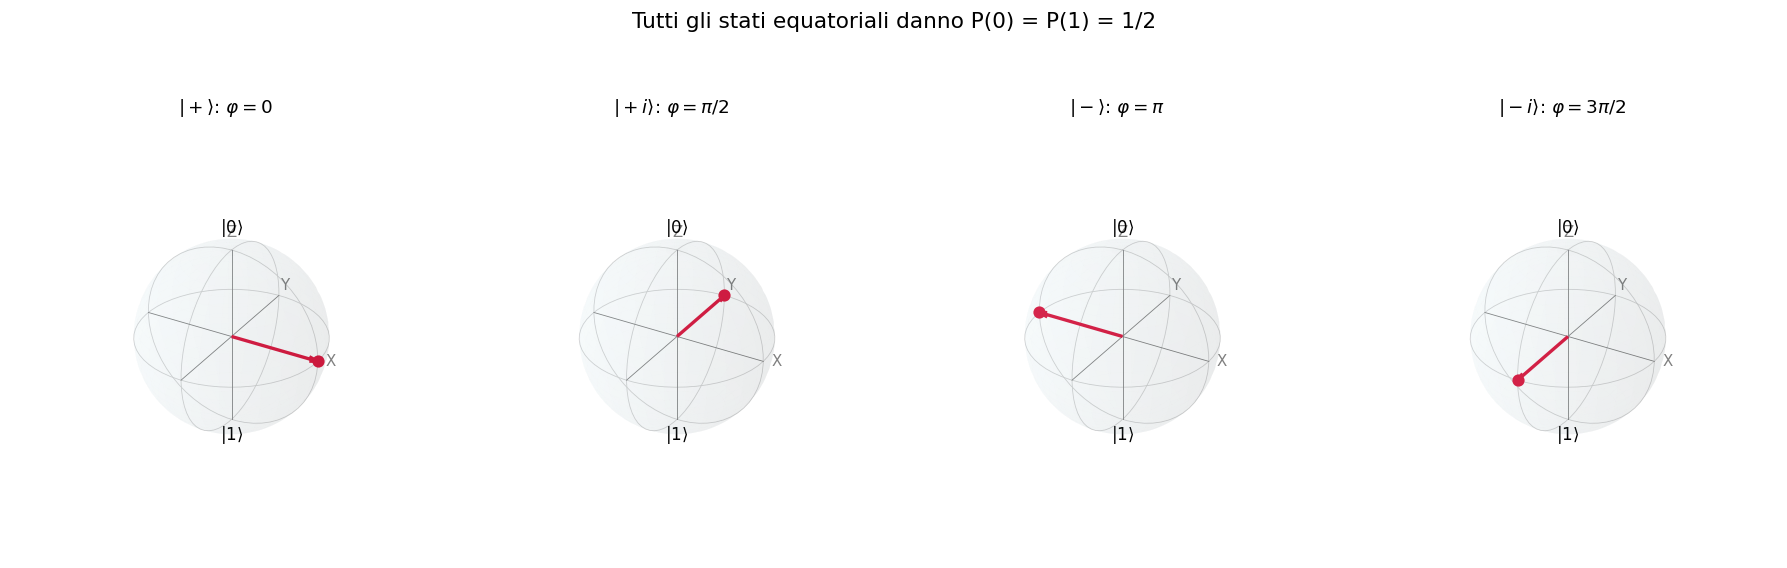

In [3]:
# Backward: all equatorial states give 50/50 measurement
fig = plt.figure(figsize=(15, 5))

equatorial_phis = [0, np.pi/2, np.pi, 3*np.pi/2]
labels = [r'$|+\rangle$: $\varphi=0$', r'$|+i\rangle$: $\varphi=\pi/2$',
          r'$|-\rangle$: $\varphi=\pi$', r'$|-i\rangle$: $\varphi=3\pi/2$']

for i, (phi, label) in enumerate(zip(equatorial_phis, labels)):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    draw_bloch_sphere(np.pi / 2, phi, ax=ax, title=label)

fig.suptitle('Tutti gli stati equatoriali danno P(0) = P(1) = 1/2', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Explore: esplora lo spazio dei qubit

Usa gli slider per variare $\theta$ e $\varphi$ e osserva come cambiano la posizione sulla sfera di Bloch, le ampiezze e le probabilità di misura.

In [9]:
def explore_qubit(theta=FloatSlider(min=0, max=np.pi, step=0.05, value=np.pi/4, description='θ'),
                  phi=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0, description='φ')):
    alpha = np.cos(theta / 2)
    beta = np.exp(1j * phi) * np.sin(theta / 2)

    fig = plt.figure(figsize=(14, 4))
    ax1 = fig.add_subplot(131, projection='3d')
    draw_bloch_sphere(theta, phi, ax=ax1, title='Sfera di Bloch')

    ax2 = fig.add_subplot(132)
    draw_amplitude_bars([alpha, beta], ax=ax2, title='Ampiezze')

    ax3 = fig.add_subplot(133)
    probs = [abs(alpha)**2, abs(beta)**2]
    ax3.bar([r'\$|0\rangle\$', r'\$|1\rangle\$'], probs, color=[PRIMARY_COLOR, ACCENT_COLOR])
    ax3.set_ylim(0, 1.05)
    ax3.set_ylabel('Probabilità')
    ax3.set_title('Probabilità di misura')

    plt.tight_layout()
    plt.show()

interact(explore_qubit);

interactive(children=(FloatSlider(value=0.7853981633974483, description='θ', max=3.141592653589793, step=0.05)…

---

### Intermezzo: i numeri complessi in 5 minuti

Prima di parlare di ampiezze, un rapido richiamo sui **numeri complessi** — il linguaggio matematico della meccanica quantistica.

Un numero complesso $z$ si può scrivere in due modi equivalenti:

**Forma cartesiana:**
$$z = a + bi, \qquad a = \text{Re}(z),\; b = \text{Im}(z), \qquad i^2 = -1$$

**Forma polare:**
$$z = r\,e^{i\theta}, \qquad r = |z| = \sqrt{a^2 + b^2}, \qquad \theta = \arg(z) = \arctan(b/a)$$

Il collegamento tra le due è la **formula di Eulero**:

$$e^{i\theta} = \cos\theta + i\sin\theta$$

Ogni numero complesso è un **punto nel piano complesso**: l'asse orizzontale è la parte reale, quello verticale è la parte immaginaria. Il modulo $r$ è la *distanza dall'origine*, la fase $\theta$ è l'*angolo* rispetto all'asse reale.

**Moltiplicare** due numeri complessi significa **sommare le fasi** e **moltiplicare i moduli**:
$$z_1 \cdot z_2 = r_1 r_2\, e^{i(\theta_1 + \theta_2)}$$

Questo è il motivo per cui le fasi sono così importanti in meccanica quantistica: quando due ampiezze si combinano, le loro fasi determinano se l'interferenza è **costruttiva** (fasi allineate → si sommano) o **distruttiva** (fasi opposte → si cancellano).

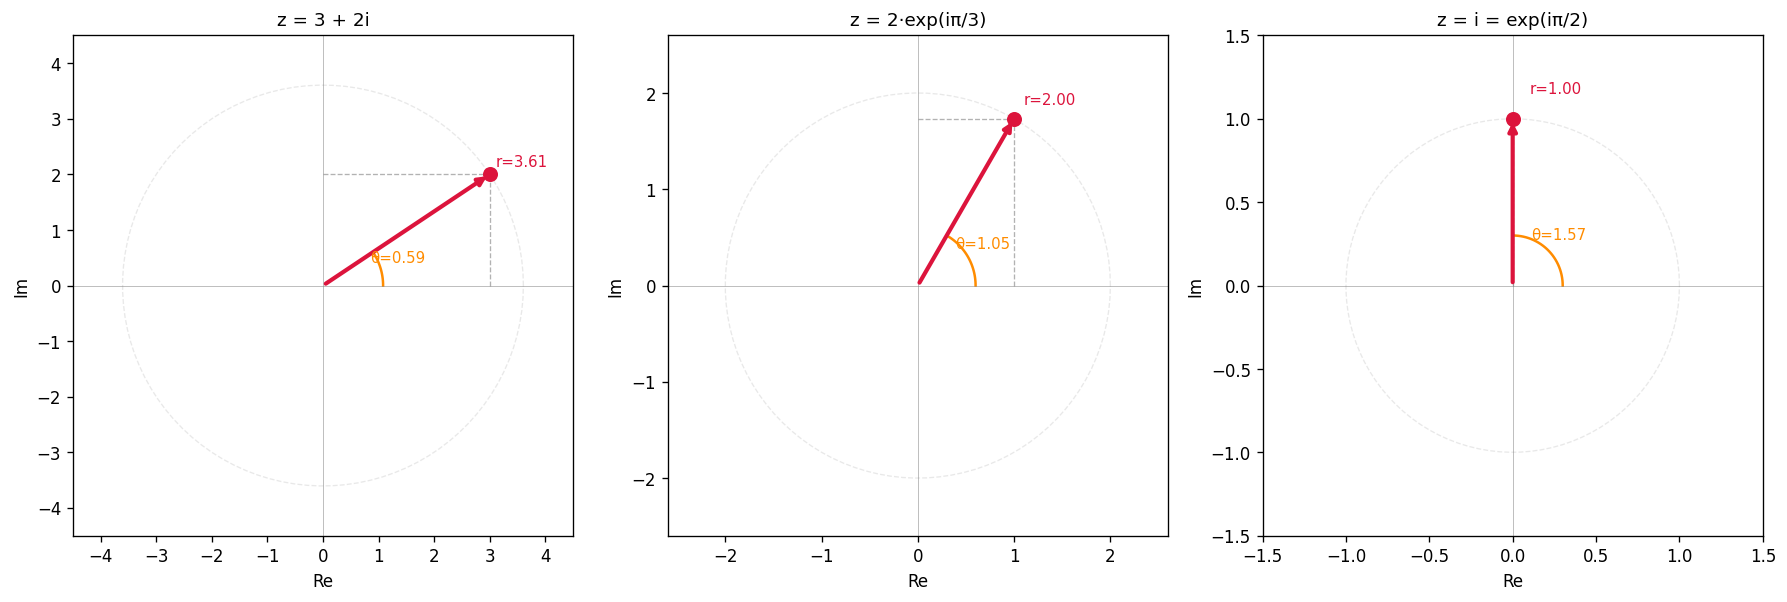

In [10]:
# Visualizzazione: un numero complesso nel piano
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

examples_z = [
    (3 + 2j, 'z = 3 + 2i'),
    (2 * np.exp(1j * np.pi/3), 'z = 2·exp(iπ/3)'),
    (1j, 'z = i = exp(iπ/2)'),
]

for ax, (z, label) in zip(axes, examples_z):
    r, theta = abs(z), np.angle(z)
    
    # Unit circle for reference
    t = np.linspace(0, 2*np.pi, 100)
    ax.plot(np.cos(t) * r, np.sin(t) * r, color=GHOST_COLOR, lw=0.8, ls='--', alpha=0.5)
    
    # Arrow from origin to z
    ax.annotate("", xy=(z.real, z.imag), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=ACCENT_COLOR, lw=2.5))
    ax.plot(z.real, z.imag, 'o', color=ACCENT_COLOR, markersize=8, zorder=10)
    
    # Projections
    ax.plot([z.real, z.real], [0, z.imag], '--', color='gray', lw=0.8, alpha=0.6)
    ax.plot([0, z.real], [z.imag, z.imag], '--', color='gray', lw=0.8, alpha=0.6)
    
    # Phase arc
    if abs(theta) > 0.05:
        arc_t = np.linspace(0, theta, 30)
        arc_r = r * 0.3
        ax.plot(arc_r * np.cos(arc_t), arc_r * np.sin(arc_t), color='darkorange', lw=1.5)
        ax.text(arc_r * 1.3 * np.cos(theta/2), arc_r * 1.3 * np.sin(theta/2),
                f'θ={theta:.2f}', fontsize=9, color='darkorange', ha='center')
    
    # Labels
    ax.text(z.real + 0.1, z.imag + 0.15, f'r={r:.2f}', fontsize=9, color=ACCENT_COLOR)
    
    lim = max(abs(z.real), abs(z.imag), 1) * 1.5
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.3)
    ax.axvline(0, color='gray', lw=0.3)
    ax.set_xlabel('Re', fontsize=10)
    ax.set_ylabel('Im', fontsize=10)
    ax.set_title(label, fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
# Widget: esplora un numero complesso nel piano
def explore_complex(r=FloatSlider(min=0, max=2, step=0.05, value=1, description='r (modulo)'),
                    theta=FloatSlider(min=-np.pi, max=np.pi, step=0.05, value=np.pi/4, description='θ (fase)')):
    z = r * np.exp(1j * theta)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Left: the number in the complex plane
    t = np.linspace(0, 2*np.pi, 100)
    ax1.plot(np.cos(t) * r, np.sin(t) * r, color=GHOST_COLOR, lw=0.8, ls='--', alpha=0.5)
    ax1.annotate("", xy=(z.real, z.imag), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="-|>", color=ACCENT_COLOR, lw=2.5))
    ax1.plot(z.real, z.imag, 'o', color=ACCENT_COLOR, markersize=10, zorder=10)
    
    # Phase arc
    if abs(theta) > 0.05:
        arc_t = np.linspace(0, theta, 30)
        arc_r = max(r * 0.3, 0.2)
        ax1.plot(arc_r * np.cos(arc_t), arc_r * np.sin(arc_t), color='darkorange', lw=2)
    
    ax1.set_xlim(-2.5, 2.5)
    ax1.set_ylim(-2.5, 2.5)
    ax1.set_aspect('equal')
    ax1.axhline(0, color='gray', lw=0.3)
    ax1.axvline(0, color='gray', lw=0.3)
    ax1.set_xlabel('Re', fontsize=11)
    ax1.set_ylabel('Im', fontsize=11)
    ax1.set_title(f'$z = {z.real:.2f} + {z.imag:.2f}i$', fontsize=12)
    ax1.grid(True, alpha=0.2)
    
    # Right: multiplication — z * z
    z2 = z * z
    for zz, label, color in [(z, 'z', ACCENT_COLOR), (z2, 'z²', PRIMARY_COLOR)]:
        ax2.annotate("", xy=(zz.real, zz.imag), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="-|>", color=color, lw=2))
        ax2.plot(zz.real, zz.imag, 'o', color=color, markersize=8, zorder=10)
        ax2.text(zz.real + 0.1, zz.imag + 0.15, label, fontsize=11, color=color, fontweight='bold')
    
    ax2.set_xlim(-5, 5)
    ax2.set_ylim(-5, 5)
    ax2.set_aspect('equal')
    ax2.axhline(0, color='gray', lw=0.3)
    ax2.axvline(0, color='gray', lw=0.3)
    ax2.set_xlabel('Re', fontsize=11)
    ax2.set_ylabel('Im', fontsize=11)
    ax2.set_title(f'Moltiplicazione: $z^2$ ha modulo $r^2={r**2:.2f}$, fase $2θ={2*theta:.2f}$', fontsize=11)
    ax2.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()

interact(explore_complex);

interactive(children=(FloatSlider(value=1.0, description='r (modulo)', max=2.0, step=0.05), FloatSlider(value=…

---

## 2. Ampiezze complesse

Ogni ampiezza $\alpha, \beta \in \mathbb{C}$ ha un **modulo** e una **fase**:

$$\alpha = |\alpha|\,e^{i\phi_\alpha}, \qquad \beta = |\beta|\,e^{i\phi_\beta}$$

Il vincolo di normalizzazione $|\alpha|^2 + |\beta|^2 = 1$ fissa i moduli, ma le fasi rimangono libere (a meno della fase globale).

**La fase non si vede nella misura**: $P(0) = |\alpha|^2$ dipende solo dal modulo. Tuttavia, le fasi relative controllano l'**interferenza** — il meccanismo chiave del quantum computing (che esploreremo nel Notebook 1).

### Forward: ampiezze nel piano complesso

Visualizziamo $\alpha$ e $\beta$ nel piano complesso per tre stati noti:

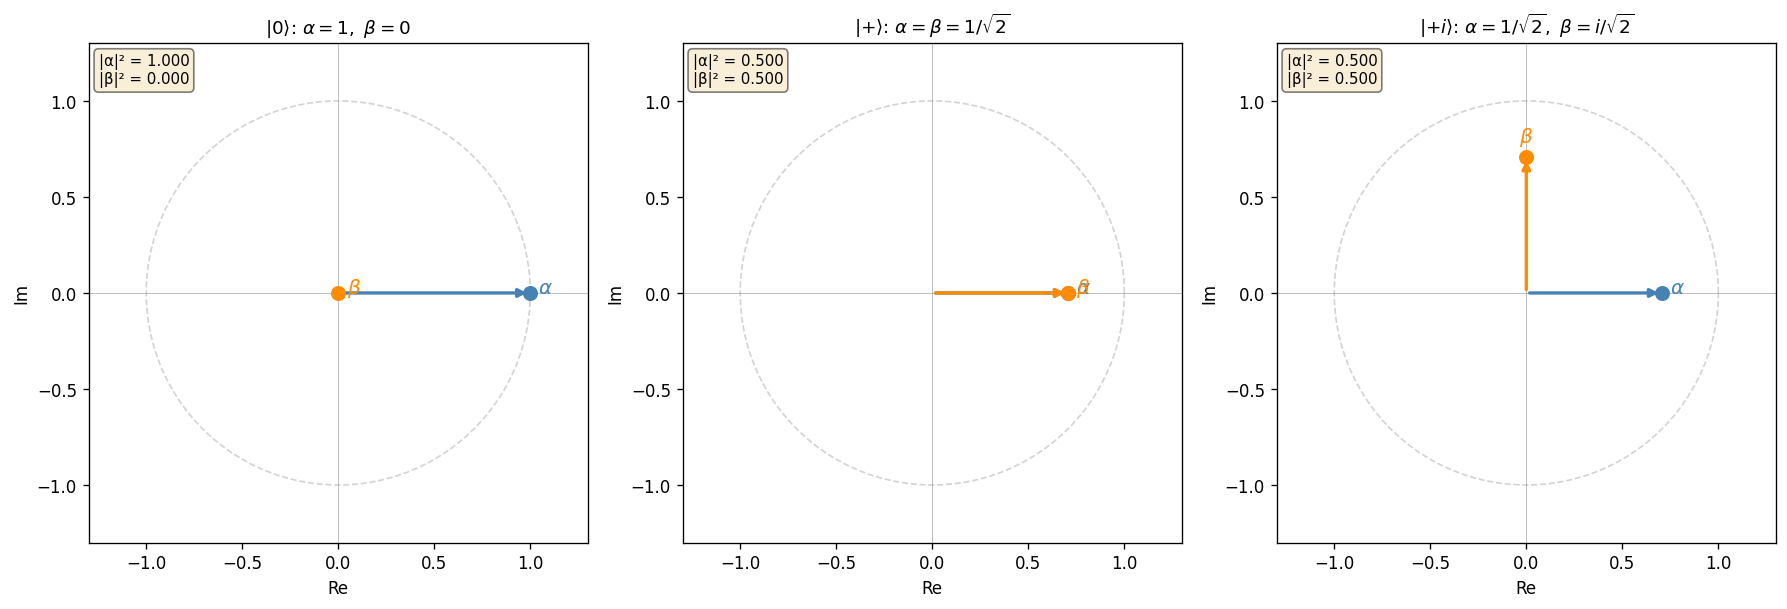

In [12]:
# Forward: complex amplitudes for three states
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

states_cp = [
    (complex(1, 0), complex(0, 0),
     r'$|0\rangle$: $\alpha=1,\ \beta=0$'),
    (1/np.sqrt(2), 1/np.sqrt(2),
     r'$|{+}\rangle$: $\alpha=\beta=1/\sqrt{2}$'),
    (1/np.sqrt(2), 1j/np.sqrt(2),
     r'$|{+i}\rangle$: $\alpha=1/\sqrt{2},\ \beta=i/\sqrt{2}$'),
]

for ax, (alpha, beta, title) in zip(axes, states_cp):
    draw_complex_plane(complex(alpha), complex(beta), ax=ax, title=title)

plt.tight_layout()
plt.show()

### Backward: "Voglio $P(0) = 0.3$. Quanti stati diversi realizzano questa probabilità?"

Se $P(0) = |\alpha|^2 = 0.3$, allora $|\alpha| = \sqrt{0.3}$. Ma la **fase** di $\alpha$ può essere qualsiasi! Nel piano complesso, $\alpha$ vive su un **cerchio** di raggio $\sqrt{0.3}$. Esistono **infiniti** stati con la stessa probabilità di misura.

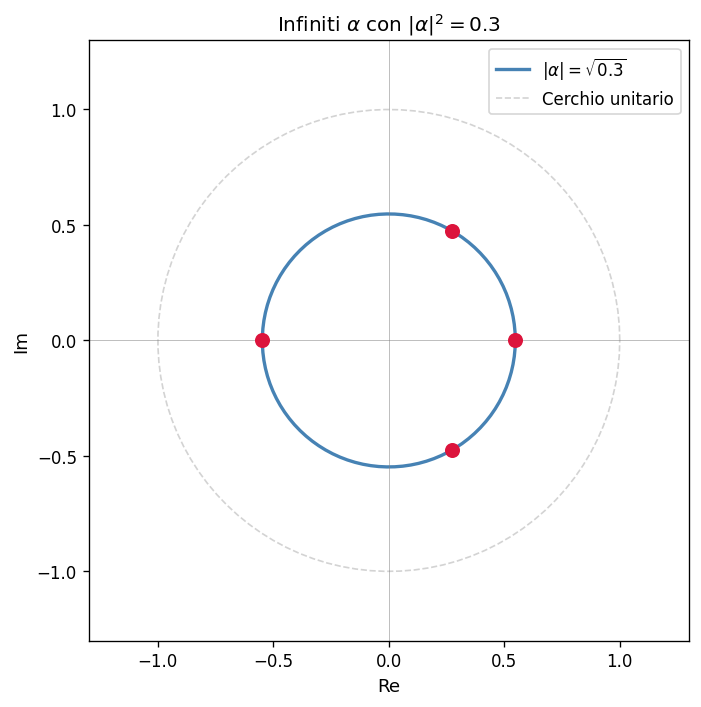

In [13]:
# Backward: circle of states with P(0) = 0.3
fig, ax = plt.subplots(figsize=(6, 6))

# Circle of radius sqrt(0.3) for alpha
r_alpha = np.sqrt(0.3)
t = np.linspace(0, 2 * np.pi, 100)
ax.plot(r_alpha * np.cos(t), r_alpha * np.sin(t), color=PRIMARY_COLOR, lw=2,
        label=r'$|\alpha| = \sqrt{0.3}$')

# Show a few specific alpha values on the circle
for phi_a in [0, np.pi/3, np.pi, 5*np.pi/3]:
    a = r_alpha * np.exp(1j * phi_a)
    ax.plot(a.real, a.imag, 'o', color=ACCENT_COLOR, markersize=8, zorder=10)

# Unit circle for reference
ax.plot(np.cos(t), np.sin(t), color=GHOST_COLOR, lw=1, ls='--', label='Cerchio unitario')

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.3)
ax.axvline(0, color='gray', lw=0.3)
ax.set_xlabel('Re', fontsize=11)
ax.set_ylabel('Im', fontsize=11)
ax.set_title(r'Infiniti $\alpha$ con $|\alpha|^2 = 0.3$', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Explore: ampiezze complesse interattive

Varia il modulo e la fase di $\alpha$; $\beta$ viene calcolato automaticamente dalla normalizzazione.

In [14]:
def explore_amplitudes(mod_alpha=FloatSlider(min=0, max=1, step=0.01, value=0.7, description=r'|α|'),
                       arg_alpha=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0, description=r'arg(α)')):
    alpha = mod_alpha * np.exp(1j * arg_alpha)
    # beta modulus from normalization; give it phase 0 for simplicity
    mod_beta = np.sqrt(max(0, 1 - mod_alpha**2))
    beta = mod_beta + 0j  # phase of beta = 0 (relative phase already in alpha)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    draw_complex_plane(alpha, beta, ax=ax1, title='Piano complesso')

    probs = [abs(alpha)**2, abs(beta)**2]
    ax2.bar([r'$|0\rangle$', r'$|1\rangle$'], probs, color=[PRIMARY_COLOR, ACCENT_COLOR])
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel('Probabilità')
    ax2.set_title(f'P(0) = {probs[0]:.3f}, P(1) = {probs[1]:.3f}')

    plt.tight_layout()
    plt.show()

interact(explore_amplitudes);

interactive(children=(FloatSlider(value=0.7, description='|α|', max=1.0, step=0.01), FloatSlider(value=0.0, de…

---

## 3. La sfera di Bloch

La mappa $(\alpha, \beta) \to (\theta, \varphi)$ identifica ogni stato puro di un qubit con un punto sulla sfera unitaria $S^2$. Le **porte quantistiche** a singolo qubit corrispondono a **rotazioni** di questa sfera:

| Porta | Matrice | Azione geometrica |
|-------|---------|-------------------|
| $X$ (NOT) | $\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$ | Rotazione di $\pi$ attorno all'asse $x$ |
| $Z$ | $\begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$ | Rotazione di $\pi$ attorno all'asse $z$ |
| $H$ (Hadamard) | $\frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$ | Rotazione di $\pi$ attorno all'asse $(x+z)/\sqrt{2}$ |

La **decomposizione universale** garantisce che qualsiasi stato puro si raggiunge da $|0\rangle$ con al più due rotazioni:

$$|\psi\rangle = R_z(\varphi)\,R_y(\theta)\,|0\rangle$$

### Forward: effetto dei gate sulla sfera di Bloch

Tre coppie prima/dopo: $X|0\rangle$, $Z|+\rangle$, $H|0\rangle$.

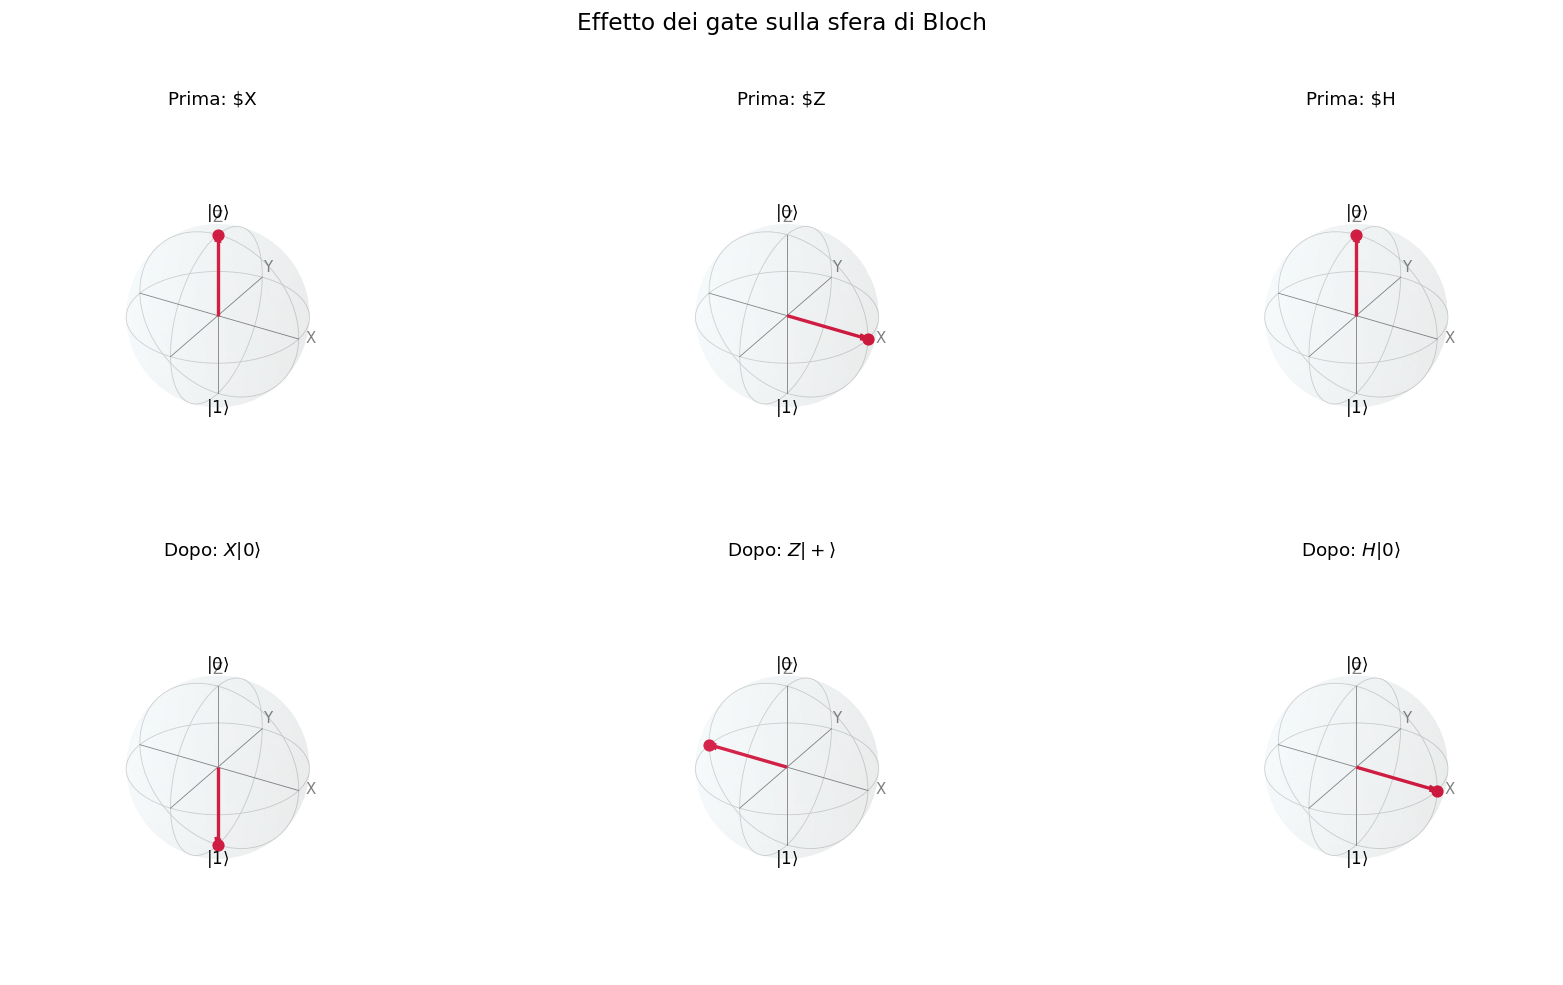

In [15]:
# Forward: gate effects on the Bloch sphere
# Helper to compute (theta, phi) from a statevector
def state_to_bloch_angles(state):
    """Convert a 2-element statevector to Bloch angles (theta, phi)."""
    state = np.array(state, dtype=complex)
    # Normalize global phase so alpha is real and positive
    if abs(state[0]) > 1e-10:
        state = state * np.exp(-1j * np.angle(state[0]))
    theta = 2 * np.arccos(np.clip(abs(state[0]), 0, 1))
    if abs(state[1]) > 1e-10:
        phi = np.angle(state[1])
    else:
        phi = 0.0
    return float(theta), float(phi % (2 * np.pi))

# Gate matrices
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

# Input states
ket0 = np.array([1, 0], dtype=complex)
ket_plus = np.array([1, 1], dtype=complex) / np.sqrt(2)

gate_demos = [
    (r'$X|0\rangle$', ket0, X),
    (r'$Z|+\rangle$', ket_plus, Z),
    (r'$H|0\rangle$', ket0, H),
]

fig = plt.figure(figsize=(15, 8))

for i, (title, psi_in, gate) in enumerate(gate_demos):
    psi_out = gate @ psi_in
    th_in, ph_in = state_to_bloch_angles(psi_in)
    th_out, ph_out = state_to_bloch_angles(psi_out)

    ax_before = fig.add_subplot(2, 3, i + 1, projection='3d')
    draw_bloch_sphere(th_in, ph_in, ax=ax_before, title=f'Prima: {title.split("|")[0]}')

    ax_after = fig.add_subplot(2, 3, i + 4, projection='3d')
    draw_bloch_sphere(th_out, ph_out, ax=ax_after, title=f'Dopo: {title}')

fig.suptitle('Effetto dei gate sulla sfera di Bloch', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Backward: "Come raggiungo un punto arbitrario sulla sfera?"

Dato un punto target $(\theta_t, \varphi_t)$, la decomposizione $R_z(\varphi)\,R_y(\theta)\,|0\rangle$ fornisce il percorso: prima ruota attorno a $y$ di $\theta$ (per scendere dal polo nord), poi attorno a $z$ di $\varphi$ (per girare sull'equatore).

$$R_y(\theta) = \begin{pmatrix} \cos\theta/2 & -\sin\theta/2 \\ \sin\theta/2 & \cos\theta/2 \end{pmatrix}, \qquad R_z(\varphi) = \begin{pmatrix} e^{-i\varphi/2} & 0 \\ 0 & e^{i\varphi/2} \end{pmatrix}$$

### Explore: costruisci uno stato con rotazioni

Scegli il punto target $(\theta_t, \varphi_t)$ e il numero di gate da visualizzare (1 = solo $R_y$, 2 = $R_z \cdot R_y$, 3 = anche lo stato iniziale).

In [16]:
def Ry(theta):
    """Rotation around y-axis."""
    return np.array([[np.cos(theta/2), -np.sin(theta/2)],
                     [np.sin(theta/2),  np.cos(theta/2)]], dtype=complex)

def Rz(phi):
    """Rotation around z-axis."""
    return np.array([[np.exp(-1j*phi/2), 0],
                     [0, np.exp(1j*phi/2)]], dtype=complex)

def explore_rotations(theta_t=FloatSlider(min=0.05, max=np.pi-0.05, step=0.05, value=np.pi/3, description='θ_target'),
                      phi_t=FloatSlider(min=0, max=2*np.pi, step=0.05, value=np.pi/4, description='φ_target'),
                      n_gates=IntSlider(min=1, max=3, value=3, description='# steps')):
    ket0_local = np.array([1, 0], dtype=complex)

    # Build trajectory
    trajectory = [('|0⟩ (start)', ket0_local)]

    state_after_ry = Ry(theta_t) @ ket0_local
    trajectory.append((f'Dopo Ry(θ={theta_t:.2f})', state_after_ry))

    state_after_rz = Rz(phi_t) @ state_after_ry
    trajectory.append((f'Dopo Rz(φ={phi_t:.2f})', state_after_rz))

    # Show only the requested number of steps
    show = trajectory[:min(n_gates + 1, len(trajectory))]

    fig = plt.figure(figsize=(5 * len(show), 5))
    for i, (label, state) in enumerate(show):
        th, ph = state_to_bloch_angles(state)
        ax = fig.add_subplot(1, len(show), i + 1, projection='3d')
        draw_bloch_sphere(th, ph, ax=ax, title=label)

    plt.tight_layout()
    plt.show()

interact(explore_rotations);

interactive(children=(FloatSlider(value=1.0471975511965976, description='θ_target', max=3.0915926535897933, mi…

---

## 4. La misura come proiezione

Misurare un qubit nella **base computazionale** $\{|0\rangle, |1\rangle\}$ produce:
- Risultato $0$ con probabilità $P(0) = |\alpha|^2$
- Risultato $1$ con probabilità $P(1) = |\beta|^2$

Dopo la misura, lo stato **collassa** nel risultato osservato: se misuriamo $0$, lo stato diventa $|0\rangle$. Tutta l'informazione sulla fase è **persa irreversibilmente**.

Questo è il **postulato della misura**: la misura quantistica è probabilistica e distruttiva. Per ricostruire le probabilità dobbiamo ripetere l'esperimento molte volte (tomografia).

### Forward: la legge dei grandi numeri in azione

Misuriamo $|+\rangle$ con $N = 10, 100, 10000$ shots. All'aumentare di $N$, le frequenze convergono alle probabilità teoriche.

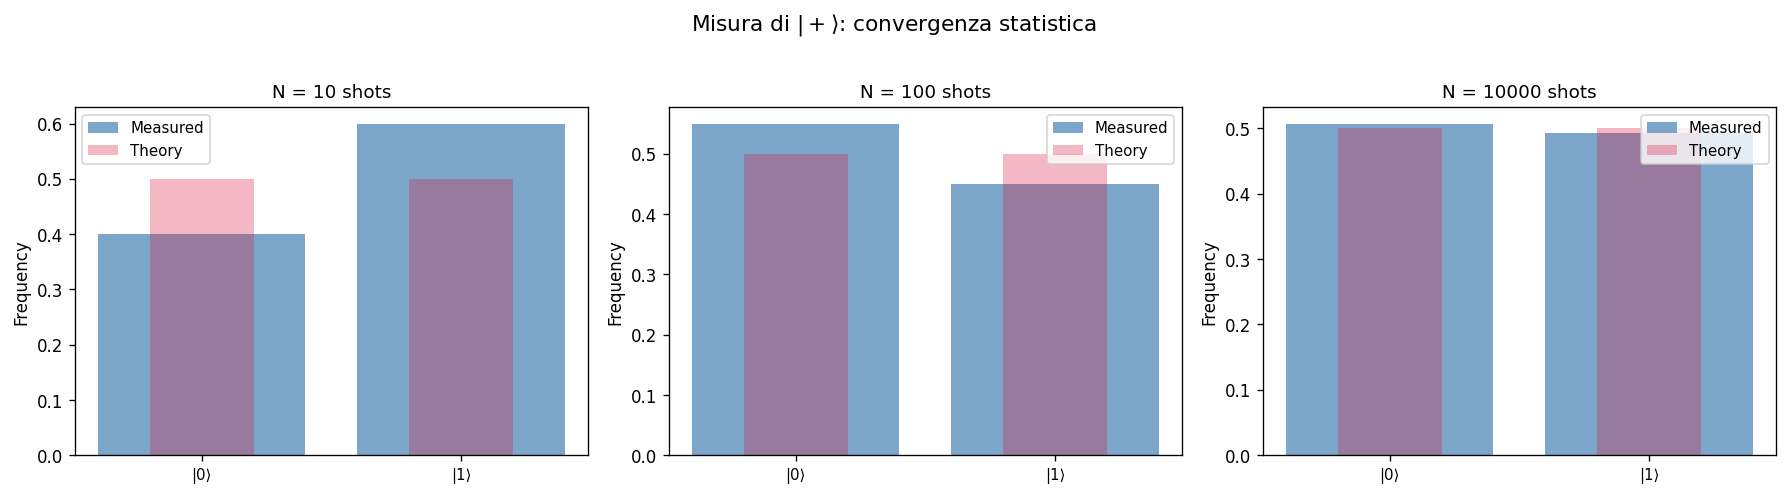

In [17]:
# Forward: measurement statistics for |+> with increasing shots
np.random.seed(42)
plus_state = np.array([1, 1], dtype=complex) / np.sqrt(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n_shots in zip(axes, [10, 100, 10000]):
    simulate_measurement(plus_state, n_shots, ax=ax, title=f'N = {n_shots} shots')

fig.suptitle(r'Misura di $|+\rangle$: convergenza statistica', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Backward: "Ho misurato 700 volte $|0\rangle$ su 1000 — che stato poteva essere?"

Se $P(0) \approx 0.7$, allora $|\alpha|^2 \approx 0.7$ e quindi:

$$\theta \approx 2\arccos\sqrt{0.7} \approx 1.17 \text{ rad}$$

Ma **$\varphi$ è completamente ignoto**! La misura nella base computazionale non rivela la fase relativa. Servono misure in basi diverse per una ricostruzione completa (tomografia quantistica).

theta stimato: 1.1593 rad (66.4°)
Ma φ può essere qualsiasi valore in [0, 2π)!


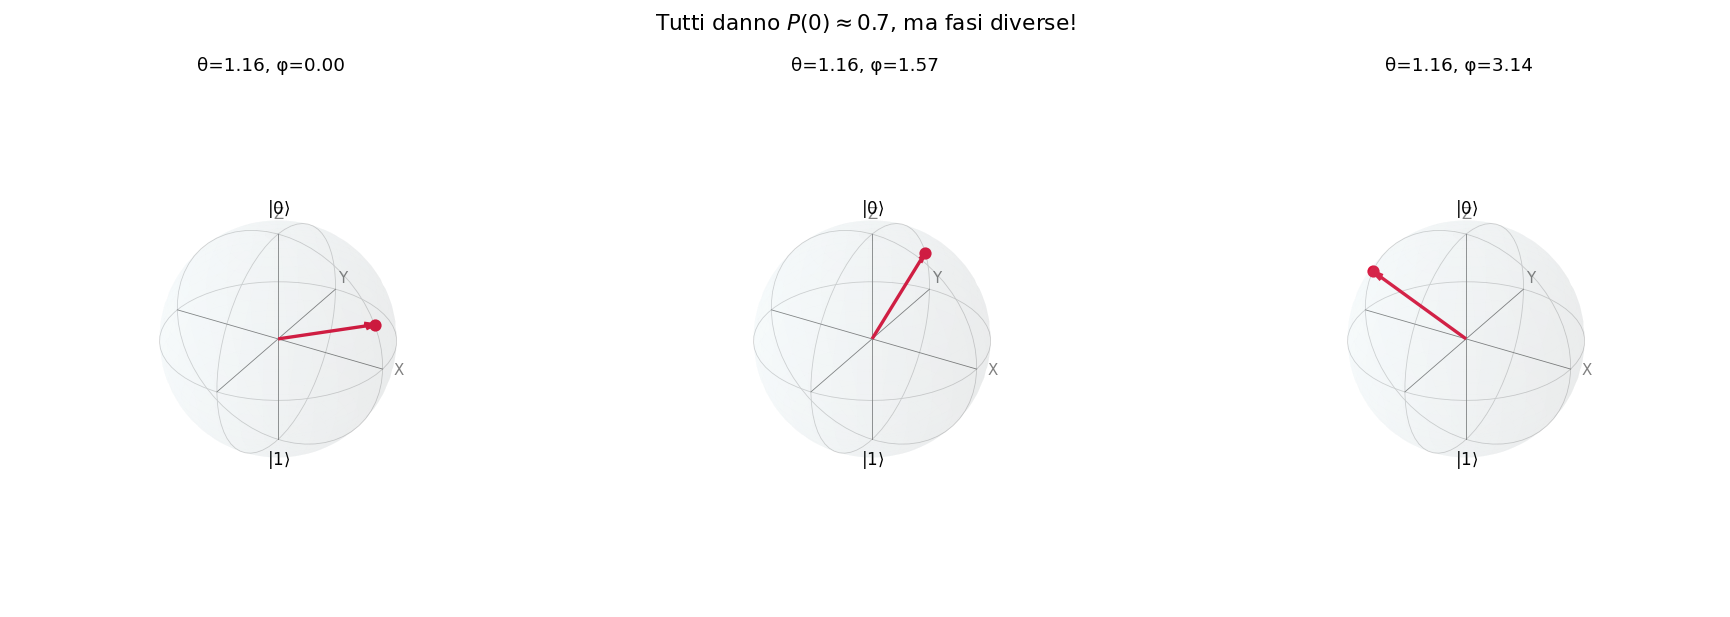

In [18]:
# Backward: theta is determined, but phi is unknown
theta_est = 2 * np.arccos(np.sqrt(0.7))
print(f"theta stimato: {theta_est:.4f} rad ({np.degrees(theta_est):.1f}°)")
print(f"Ma φ può essere qualsiasi valore in [0, 2π)!")

fig = plt.figure(figsize=(15, 5))
for i, phi_val in enumerate([0, np.pi/2, np.pi]):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    draw_bloch_sphere(theta_est, phi_val, ax=ax,
                      title=f'θ={theta_est:.2f}, φ={phi_val:.2f}')

fig.suptitle(r'Tutti danno $P(0) \approx 0.7$, ma fasi diverse!', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Explore: misura interattiva

Varia $\theta$ (che determina le probabilità) e il numero di shots $N$ per osservare la convergenza statistica.

In [19]:
def explore_measurement(theta=FloatSlider(min=0.05, max=np.pi-0.05, step=0.05, value=np.pi/3, description='θ'),
                        log_N=FloatSlider(min=1, max=4, step=0.1, value=2, description='log10(N)')):
    n_shots = int(10 ** log_N)
    alpha = np.cos(theta / 2)
    beta = np.sin(theta / 2)
    state = np.array([alpha, beta], dtype=complex)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    simulate_measurement(state, n_shots, ax=ax1,
                         title=f'N = {n_shots} shots, θ = {theta:.2f}')

    # Show Bloch sphere
    ax_bloch = fig.add_subplot(122, projection='3d')
    # Remove the flat ax2 and replace
    ax2.remove()
    draw_bloch_sphere(theta, 0, ax=ax_bloch, title=f'Stato: θ={theta:.2f}')

    plt.tight_layout()
    plt.show()

interact(explore_measurement);

interactive(children=(FloatSlider(value=1.0471975511965976, description='θ', max=3.0915926535897933, min=0.05,…

---

## 5. Multi-qubit: il prodotto tensoriale

Due qubit indipendenti $|\psi_1\rangle$ e $|\psi_2\rangle$ formano un sistema composito tramite il **prodotto tensoriale**:

$$|\psi_1\rangle \otimes |\psi_2\rangle = (\alpha_1|0\rangle + \beta_1|1\rangle) \otimes (\alpha_2|0\rangle + \beta_2|1\rangle)$$

$$= \alpha_1\alpha_2|00\rangle + \alpha_1\beta_2|01\rangle + \beta_1\alpha_2|10\rangle + \beta_1\beta_2|11\rangle$$

In generale:
- **2 qubit** $\to$ $2^2 = 4$ ampiezze
- **3 qubit** $\to$ $2^3 = 8$ ampiezze
- **$n$ qubit** $\to$ $2^n$ ampiezze

Questa crescita esponenziale è la ragione per cui simulare sistemi quantistici su computer classici è così costoso — e perché i computer quantistici sono potenzialmente potenti.

Uno stato a 2 qubit che **può** essere scritto come prodotto tensoriale si dice **separabile**. Se non è possibile, è **entangled** (Sezione 6).

### Forward: prodotti tensoriali di stati noti

Calcoliamo $|0\rangle \otimes |+\rangle$ e $|+\rangle \otimes |+\rangle$:

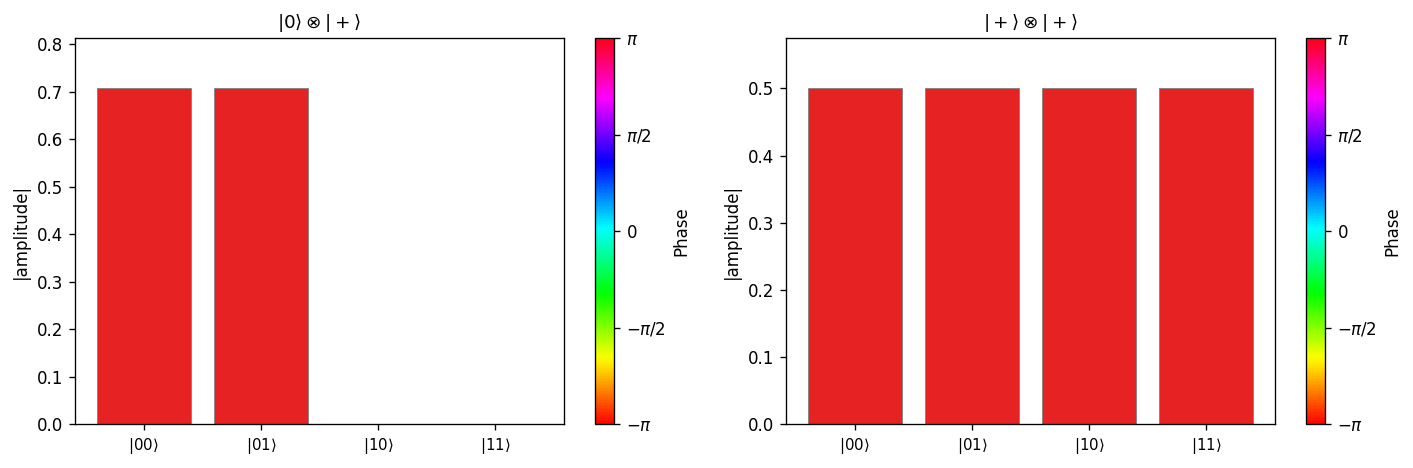

In [20]:
# Forward: tensor products
ket0_tp = np.array([1, 0], dtype=complex)
ket1_tp = np.array([0, 1], dtype=complex)
ket_plus_tp = np.array([1, 1], dtype=complex) / np.sqrt(2)

# |0> tensor |+>
state_0_plus = np.kron(ket0_tp, ket_plus_tp)
# |+> tensor |+>
state_plus_plus = np.kron(ket_plus_tp, ket_plus_tp)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

draw_amplitude_bars(state_0_plus, ax=ax1, title=r'$|0\rangle \otimes |+\rangle$')
ax1.set_xticks(range(4))
ax1.set_xticklabels([r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'])

draw_amplitude_bars(state_plus_plus, ax=ax2, title=r'$|+\rangle \otimes |+\rangle$')
ax2.set_xticks(range(4))
ax2.set_xticklabels([r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'])

plt.tight_layout()
plt.show()

### Backward: "Questo vettore a 4 componenti è separabile?"

Un vettore $|\psi\rangle = a|00\rangle + b|01\rangle + c|10\rangle + d|11\rangle$ è separabile se e solo se $ad = bc$ (il determinante della matrice $\begin{pmatrix} a & b \\ c & d \end{pmatrix}$ è zero).

Confrontiamo un esempio separabile e uno non separabile:

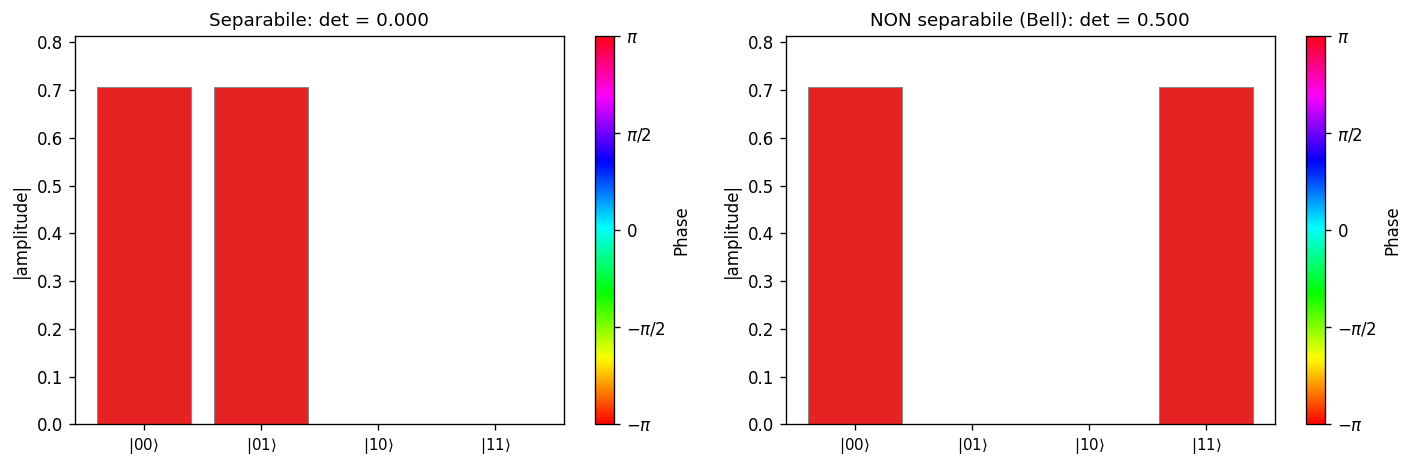

Stato separabile |0⟩|+⟩: ad - bc = 0.0000 (= 0 → separabile)
Stato di Bell (|00⟩+|11⟩)/√2: ad - bc = 0.5000 (≠ 0 → entangled!)


In [21]:
# Backward: separability test
# Separable: |0>|+> = (1/sqrt2)(|00> + |01>)
sep_state = np.array([1, 1, 0, 0], dtype=complex) / np.sqrt(2)
a, b, c, d = sep_state
det_sep = abs(a * d - b * c)

# Non-separable (Bell state): (|00> + |11>) / sqrt(2)
bell_state = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
a2, b2, c2, d2 = bell_state
det_bell = abs(a2 * d2 - b2 * c2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels_2q = [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$']

draw_amplitude_bars(sep_state, ax=ax1, title=f'Separabile: det = {det_sep:.3f}')
ax1.set_xticks(range(4))
ax1.set_xticklabels(labels_2q)

draw_amplitude_bars(bell_state, ax=ax2, title=f'NON separabile (Bell): det = {det_bell:.3f}')
ax2.set_xticks(range(4))
ax2.set_xticklabels(labels_2q)

plt.tight_layout()
plt.show()

print(f"Stato separabile |0⟩|+⟩: ad - bc = {det_sep:.4f} (= 0 → separabile)")
print(f"Stato di Bell (|00⟩+|11⟩)/√2: ad - bc = {det_bell:.4f} (≠ 0 → entangled!)")

### Explore: prodotto tensoriale interattivo

Varia i parametri dei due qubit e osserva il vettore a 4 componenti risultante.

In [22]:
def explore_tensor_product(theta1=FloatSlider(min=0, max=np.pi, step=0.05, value=np.pi/2, description='θ1'),
                           phi1=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0, description='φ1'),
                           theta2=FloatSlider(min=0, max=np.pi, step=0.05, value=np.pi/3, description='θ2'),
                           phi2=FloatSlider(min=0, max=2*np.pi, step=0.05, value=0, description='φ2')):
    # Build single-qubit states
    q1 = np.array([np.cos(theta1/2), np.exp(1j*phi1)*np.sin(theta1/2)])
    q2 = np.array([np.cos(theta2/2), np.exp(1j*phi2)*np.sin(theta2/2)])

    # Tensor product
    tensor = np.kron(q1, q2)

    fig, ax = plt.subplots(figsize=(8, 4))
    draw_amplitude_bars(tensor, ax=ax, title='Prodotto tensoriale')
    ax.set_xticks(range(4))
    ax.set_xticklabels([r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'])

    # Show probabilities as text
    probs = np.abs(tensor)**2
    info = '  '.join([f'P({b})={p:.3f}' for b, p in zip(['00','01','10','11'], probs)])
    ax.set_xlabel(info, fontsize=9)

    plt.tight_layout()
    plt.show()

interact(explore_tensor_product);

interactive(children=(FloatSlider(value=1.5707963267948966, description='θ1', max=3.141592653589793, step=0.05…

---

## 6. Entanglement

Il **CNOT** (Controlled-NOT) è un gate a 2 qubit che **flippa il secondo qubit se il primo è $|1\rangle$**:

$$\text{CNOT} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

Applicato allo stato $|+\rangle|0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |10\rangle)$:

$$\text{CNOT}|+0\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle) = |\Phi^+\rangle$$

Questo è uno **stato di Bell**: non può essere scritto come prodotto tensoriale di due qubit singoli. I due qubit sono **entangled**: misurare uno determina istantaneamente l'altro.

- Se misuro il primo qubit e ottengo $|0\rangle$, il secondo è certamente $|0\rangle$
- Se misuro il primo qubit e ottengo $|1\rangle$, il secondo è certamente $|1\rangle$

L'entanglement è una risorsa fondamentale per il quantum computing. Il formalismo completo sarà sviluppato nel Notebook 2.

### Forward: lo stato di Bell $|\Phi^+\rangle$

Ampiezze e tabella di correlazione per $(|00\rangle + |11\rangle)/\sqrt{2}$:

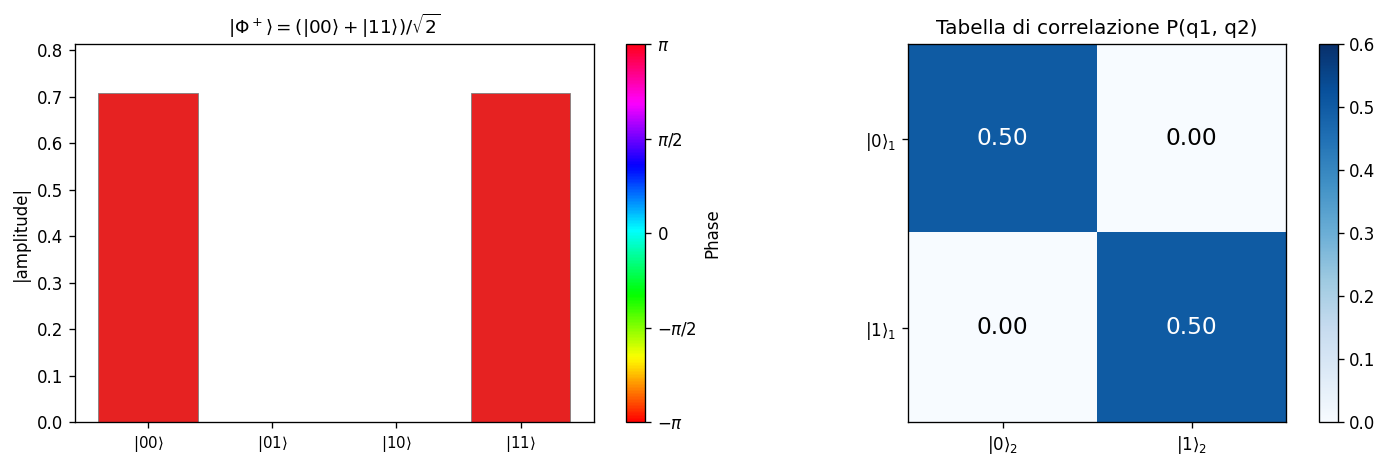

In [23]:
# Forward: Bell state amplitudes and correlations
bell_phi_plus = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
labels_2q_full = [r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Amplitude bars
draw_amplitude_bars(bell_phi_plus, ax=ax1, title=r'$|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$')
ax1.set_xticks(range(4))
ax1.set_xticklabels(labels_2q_full)

# Correlation table as heatmap
probs_2d = np.abs(bell_phi_plus.reshape(2, 2))**2
im = ax2.imshow(probs_2d, cmap='Blues', vmin=0, vmax=0.6)
ax2.set_xticks([0, 1])
ax2.set_xticklabels([r'$|0\rangle_2$', r'$|1\rangle_2$'])
ax2.set_yticks([0, 1])
ax2.set_yticklabels([r'$|0\rangle_1$', r'$|1\rangle_1$'])
ax2.set_title('Tabella di correlazione P(q1, q2)')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{probs_2d[i,j]:.2f}', ha='center', va='center', fontsize=14,
                 color='white' if probs_2d[i,j] > 0.3 else 'black')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

### Backward: "Voglio che misurando il primo qubit in $|0\rangle$, il secondo sia certamente $|1\rangle$"

Serve uno stato dove $|0\rangle$ del primo sia **sempre** accompagnato da $|1\rangle$ del secondo. La risposta è:

$$|\Psi^+\rangle = \frac{1}{\sqrt{2}}(|01\rangle + |10\rangle)$$

Questo è un altro stato di Bell, con correlazione **anti-parallela**.

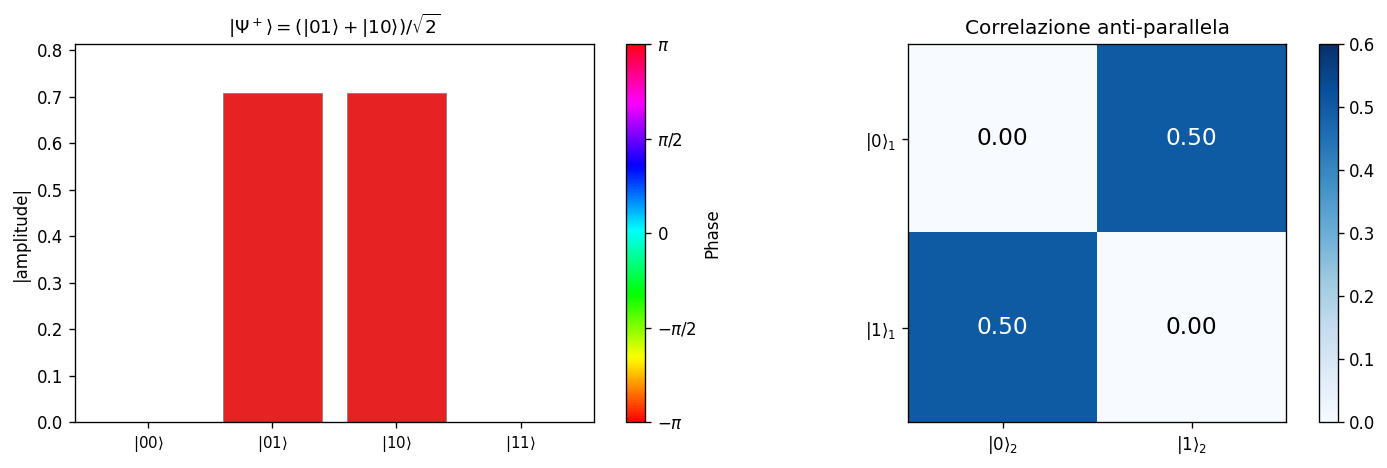

In [24]:
# Backward: anti-correlated Bell state
bell_psi_plus = np.array([0, 1, 1, 0], dtype=complex) / np.sqrt(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

draw_amplitude_bars(bell_psi_plus, ax=ax1, title=r'$|\Psi^+\rangle = (|01\rangle + |10\rangle)/\sqrt{2}$')
ax1.set_xticks(range(4))
ax1.set_xticklabels(labels_2q_full)

probs_2d_psi = np.abs(bell_psi_plus.reshape(2, 2))**2
im2 = ax2.imshow(probs_2d_psi, cmap='Blues', vmin=0, vmax=0.6)
ax2.set_xticks([0, 1])
ax2.set_xticklabels([r'$|0\rangle_2$', r'$|1\rangle_2$'])
ax2.set_yticks([0, 1])
ax2.set_yticklabels([r'$|0\rangle_1$', r'$|1\rangle_1$'])
ax2.set_title('Correlazione anti-parallela')
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{probs_2d_psi[i,j]:.2f}', ha='center', va='center', fontsize=14,
                 color='white' if probs_2d_psi[i,j] > 0.3 else 'black')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

### Explore: dall'assenza all'entanglement massimo

Lo stato $\cos(t)|00\rangle + \sin(t)|11\rangle$ interpola tra:
- $t = 0$: stato separabile $|00\rangle$ (nessun entanglement)
- $t = \pi/4$: stato di Bell massimamente entangled

In [25]:
def explore_entanglement(t=FloatSlider(min=0, max=np.pi/2, step=0.02, value=0, description='t')):
    state = np.array([np.cos(t), 0, 0, np.sin(t)], dtype=complex)
    probs = np.abs(state)**2

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Amplitude bars
    draw_amplitude_bars(state, ax=ax1, title=f'cos(t)|00⟩ + sin(t)|11⟩,  t = {t:.2f}')
    ax1.set_xticks(range(4))
    ax1.set_xticklabels([r'$|00\rangle$', r'$|01\rangle$', r'$|10\rangle$', r'$|11\rangle$'])

    # Correlation table
    probs_2d_w = probs.reshape(2, 2)
    im = ax2.imshow(probs_2d_w, cmap='Blues', vmin=0, vmax=0.6)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels([r'$|0\rangle_2$', r'$|1\rangle_2$'])
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels([r'$|0\rangle_1$', r'$|1\rangle_1$'])
    for i in range(2):
        for j in range(2):
            ax2.text(j, i, f'{probs_2d_w[i,j]:.3f}', ha='center', va='center', fontsize=13,
                     color='white' if probs_2d_w[i,j] > 0.3 else 'black')
    plt.colorbar(im, ax=ax2)

    # Concurrence as entanglement measure
    concurrence = abs(np.sin(2 * t))
    sep_label = 'Separabile' if concurrence < 0.01 else ('Max entangled' if concurrence > 0.99 else 'Parzialmente entangled')
    ax2.set_title(f'Correlazione  (concurrence = {concurrence:.3f}: {sep_label})')

    plt.tight_layout()
    plt.show()

interact(explore_entanglement);

interactive(children=(FloatSlider(value=0.0, description='t', max=1.5707963267948966, step=0.02), Output()), _…

---

## Riepilogo: bit classico vs qubit

| Proprietà | Bit classico | Qubit |
|-----------|-------------|-------|
| **Spazio degli stati** | $\{0, 1\}$ (discreto, 2 punti) | $\mathbb{C}^2$ con $\|\psi\| = 1$ (continuo, sfera $S^2$) |
| **Rappresentazione** | Un valore: $0$ o $1$ | $\alpha\|0\rangle + \beta\|1\rangle$ con $\|\alpha\|^2 + \|\beta\|^2 = 1$ |
| **Informazione** | 1 bit | 2 parametri reali $(\theta, \varphi)$ |
| **Lettura** | Deterministica: leggi il valore | Probabilistica: $P(0)=\|\alpha\|^2$, poi collasso |
| **$n$ sistemi** | $n$ bit $\to$ $n$ valori | $n$ qubit $\to$ $2^n$ ampiezze complesse |
| **Correlazioni** | Classiche (locale) | Entanglement (non-locale, non fattorizzabile) |
| **Operazioni** | Porte logiche (AND, OR, NOT) | Rotazioni unitarie sulla sfera di Bloch |

**Prossimo notebook**: Fasi, interferenza e il meccanismo alla base del quantum computing.